## Import libraries

In [34]:
from datasets import load_dataset, get_dataset_config_names
import matplotlib.pyplot as plt
import pandas as pd

## The number of language available in each dataset

BELEBELE: 122
XStoryCloze: 11
XCOPA: 21


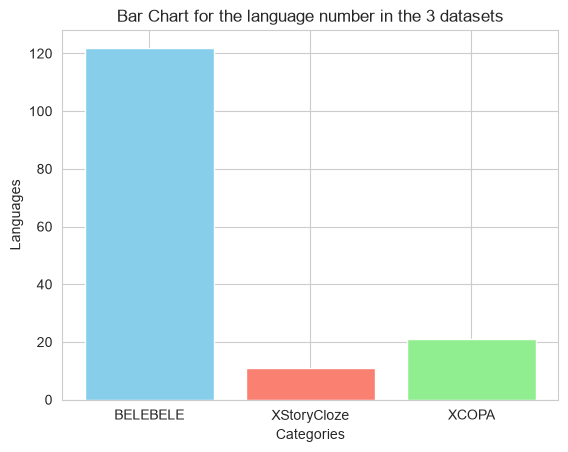

In [35]:

# Get configurations
belebele_configs = set(
    get_dataset_config_names("facebook/belebele")
)

xstory_configs = set(
    get_dataset_config_names("juletxara/xstory_cloze")
)

xcopa_configs = set(
    get_dataset_config_names("cambridgeltl/xcopa")
)

print("BELEBELE:", len(belebele_configs))
print("XStoryCloze:", len(xstory_configs))
print("XCOPA:", len(xcopa_configs))

#Graph
categories = ['BELEBELE', 'XStoryCloze', 'XCOPA']
values = [ len(belebele_configs), len(xstory_configs), len(xcopa_configs)]

# Create the bar chart
plt.bar(categories, values, color=['skyblue', 'salmon', 'lightgreen'])

# Add labels and a title
plt.xlabel('Categories')
plt.ylabel('Languages')
plt.title('Bar Chart for the language number in the 3 datasets')

# Display the chart
plt.show()

## Load data (For simplicity we choose 5 languages for the visualizing).

In [36]:
#BELEBELE
belebele_languages = {
    "Spanish": "spa_Latn",
    "Chinese": "zho_Hans",
    "Hindi": "hin_Deva",
    "Swahili": "swh_Latn",
    "Indonesian": "ind_Latn"
}

belebele = {}

for language, config in belebele_languages.items():
    print(f"Loading BELEBELE: {language}")

    belebele[language] = load_dataset(
        "facebook/belebele",
        config
    )

print("BELEBELE loaded successfully!")

Loading BELEBELE: Spanish
Loading BELEBELE: Chinese
Loading BELEBELE: Hindi
Loading BELEBELE: Swahili
Loading BELEBELE: Indonesian
BELEBELE loaded successfully!


In [37]:
# XStoryCloze


xstory_languages = {
    "Spanish": "es",
    "Chinese": "zh",
    "Hindi": "hi",
    "Swahili": "sw",
    "Indonesian": "id"
}

xstorycloze = {}

for language, config in xstory_languages.items():
    print(f"Loading XStoryCloze: {language}")

    xstorycloze[language] = load_dataset(
        "juletxara/xstory_cloze",
        config
    )

print("XStoryCloze loaded successfully!")





Loading XStoryCloze: Spanish
Loading XStoryCloze: Chinese
Loading XStoryCloze: Hindi
Loading XStoryCloze: Swahili
Loading XStoryCloze: Indonesian
XStoryCloze loaded successfully!


In [38]:

# XCOPA
xcopa_configs = get_dataset_config_names(
    "cambridgeltl/xcopa"
)

xcopa_languages = {
    "Chinese": "zh",
    "Indonesian": "id",
    "Italian": "it",
    "Swahili": "sw",
    "Turkish": "tr"
}

xcopa = {}

for language, config in xcopa_languages.items():
    print(f"Loading XCOPA: {language}")
    xcopa[language] = load_dataset(
        "cambridgeltl/xcopa",
        config
    )

print("XCOPA loaded!")


Loading XCOPA: Chinese
Loading XCOPA: Indonesian
Loading XCOPA: Italian
Loading XCOPA: Swahili
Loading XCOPA: Turkish
XCOPA loaded!


## Show what the data look like for each dataset (In Chinese)

In [39]:
print("========== BELEBELE ==========")
print(belebele["Chinese"])

print("\n========== XSTORYCLOZE ==========")
print(xstorycloze["Chinese"])

print("\n========== XCOPA ==========")
print(xcopa["Chinese"])


========== BELEBELE ==========
DatasetDict({
    test: Dataset({
        features: ['link', 'question_number', 'flores_passage', 'question', 'mc_answer1', 'mc_answer2', 'mc_answer3', 'mc_answer4', 'correct_answer_num', 'dialect', 'ds'],
        num_rows: 900
    })
})

========== XSTORYCLOZE ==========
DatasetDict({
    train: Dataset({
        features: ['story_id', 'input_sentence_1', 'input_sentence_2', 'input_sentence_3', 'input_sentence_4', 'sentence_quiz1', 'sentence_quiz2', 'answer_right_ending'],
        num_rows: 360
    })
    eval: Dataset({
        features: ['story_id', 'input_sentence_1', 'input_sentence_2', 'input_sentence_3', 'input_sentence_4', 'sentence_quiz1', 'sentence_quiz2', 'answer_right_ending'],
        num_rows: 1511
    })
})

========== XCOPA ==========
DatasetDict({
    validation: Dataset({
        features: ['premise', 'choice1', 'choice2', 'question', 'label', 'idx', 'changed'],
        num_rows: 100
    })
    test: Dataset({
        features: ['premise

## In dataframe

In [40]:
print("BELEBELE")
display(belebele["Chinese"]["test"].to_pandas().head(4).T)

print("XStoryCloze")
split = list(xstorycloze["Chinese"].keys())[0]
display(xstorycloze["Chinese"][split].to_pandas().head(4).T)

print("XCOPA")
split = list(xcopa["Chinese"].keys())[0]
display(xcopa["Chinese"][split].to_pandas().head(4).T)


BELEBELE


,0,1,2,3
link,https://en.wikibooks.org/wiki/Accordion/Right_...,https://en.wikibooks.org/wiki/Accordion/Right_...,https://en.wikibooks.org/wiki/All_About_Conver...,https://en.wikibooks.org/wiki/All_About_Conver...
question_number,1,2,1,2
flores_passage,确保你的手尽可能地放松，同时仍可以正确地敲击所有的音符—手指也尽量不要做太多无关的动作。 这...,确保你的手尽可能地放松，同时仍可以正确地敲击所有的音符—手指也尽量不要做太多无关的动作。 这...,在尝试将电影转换成 DVD 格式时，最常见的问题之一是过度扫描。 大多数电视节目都是为娱乐大...,在尝试将电影转换成 DVD 格式时，最常见的问题之一是过度扫描。 大多数电视节目都是为娱乐大...
question,根据这段文字，以下哪项不会被认为是成功演奏手风琴的准确技巧？,在演奏手风琴时，以下哪些做法可以提高音量？,为什么电视画面的边框被裁剪了？,根据这段文字，将电影转换成 DVD 格式时，可能会遇到以下哪个问题？
mc_answer1,用力敲击琴键来提升音量,更快的速度,为了让字幕能够显示,图像未能覆盖住整个屏幕
mc_answer2,尽量减少不必要的动作来节省体力,更用力,为了让图像能覆盖住整个屏幕,字幕被部分裁剪掉
mc_answer3,在手部放松的同时注意正确敲击音符,少用力,为了便于将其转换成其他格式,图像覆盖住整个屏幕
mc_answer4,以更快的速度拉风箱来提升音量,更少的手指动作,为了裁剪太靠近底部的字幕,边框被裁剪掉
correct_answer_num,1,1,2,2
dialect,zho_Hans,zho_Hans,zho_Hans,zho_Hans


XStoryCloze


,0,1,2,3
story_id,138d5bfb-05cc-41e3-bf2c-fa85ebad14e2,bff9f820-9605-4875-b9af-fe6f14d04256,e8f628d5-9f97-40ed-8611-fc0e774673c4,f5226bfe-9f26-4377-b05f-3d9568dbdec1
input_sentence_1,瑞克生长于一个坎坷动荡的家庭。,拉文需要为她朋友办的派对准备一些东西。,多年来，莎拉一直梦想前往欧洲。,吉娜担心管状的曲奇面团会很恶心。
input_sentence_2,他从来没有在家庭中得到有力支持，因此转而投身于了帮派。,她决定烤一批巧克力布朗尼。,她终于存够了旅费。,她很高兴地发现她想错了。
input_sentence_3,不久前瑞克在一宗抢劫案中中弹。,她选择了一个食谱并严格遵守了食谱的要求。,她落地在西班牙，然后向东穿越整个大陆。,用管状面团做的曲奇和从头开始制作的一样好。
input_sentence_4,这件事让他改过自新、重新做人。,拉文尝了一个布朗尼来确保它品尝起来美味。,她不喜欢所有一切都有那么大的不同。,吉娜打算只吃2个饼干，并把余下的留起来。
sentence_quiz1,他现在很开心。,布朗尼实在是太美味了，拉文吃了两个。,莎拉随后下决心搬到欧洲。,吉娜太喜欢这些曲奇了，她一口气把它们吃光了。
sentence_quiz2,他加入了一个帮派。,拉文没去她朋友的派对。,莎拉决定相较于欧洲，她更喜欢她的家乡。,吉娜在她的教会里分发了饼干。
answer_right_ending,1,1,2,1


XCOPA


,0,1,2,3
premise,那人打开水龙头。,这个女孩在麦片粥中发现了一个虫子。,女人退休了。,我想节约能源。
choice1,厕所里满是水。,她向碗里倒了牛奶。,她领了退休金。,我在空着的房间里扫了地板。
choice2,水从水龙头喷口流出。,她没了食欲。,她还清了抵押贷款。,我把空房间里的灯关了。
question,effect,effect,effect,effect
label,1,1,0,1
idx,0,1,2,3
changed,False,False,True,False
